In [47]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
# Charger les données
data = pd.read_csv("../data/city_lifestyle_dataset.csv")

In [49]:
# Afficher un aperçu des données
data.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [50]:
# Garder uniquement les colonnes numériques
data_numeric = data.select_dtypes(include=['number'])

In [51]:
# Standardiser les données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

In [52]:
# Appliquer la PCA
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_scaled)

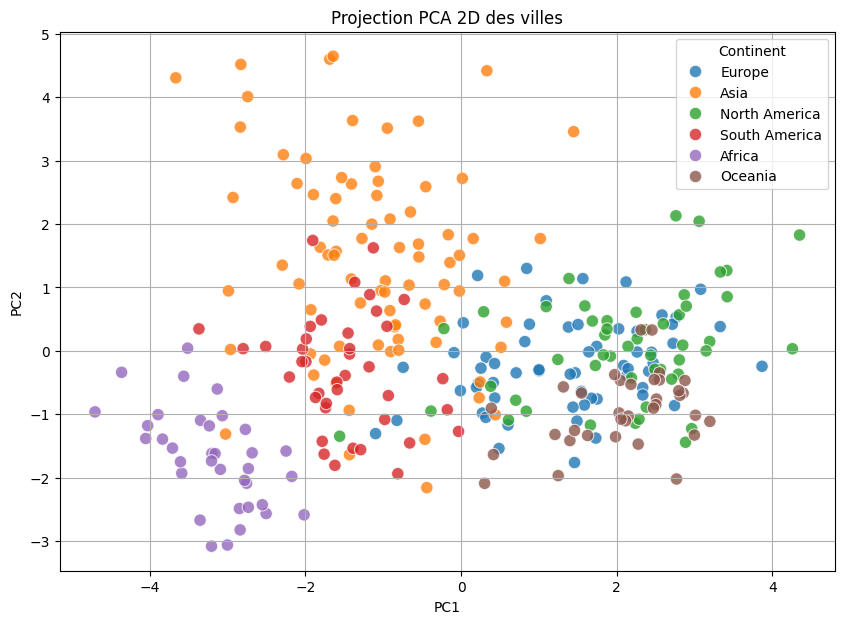

In [53]:
# Ajouter le continent au DataFrame projeté
pca_df = pd.DataFrame(data_2d, columns=['PC1','PC2'])
pca_df['country'] = data['country']

# Visualiser les données
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='country',
    palette='tab10',
    s=80,
    alpha=0.8
)
plt.title("Projection PCA 2D des villes")
plt.legend(title="Continent")
plt.grid(True)
plt.show()

In [54]:
print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale capturée :", sum(pca.explained_variance_ratio_))

Variance expliquée : [0.53805804 0.25833116]
Variance totale capturée : 0.7963892000125801


Les deux premières composantes capturent respectivement 53.8% et 25.8%, soit presque 80% de la variance totale. Cela montre que la projection en deux dimensions conserve une grande partie de l’information du jeu de données.

La visualisation met en évidence une structuration par continents. Les villes européennes et nord-américaines se regroupent majoritairement du côté positif de la première composante, tandis que les villes africaines se situent davantage du côté négatif. Les villes asiatiques présentent une dispersion plus importante, traduisant une plus grande hétérogénéité de leurs profils. Malgré certaines zones de chevauchement entre continents, la PCA révèle des tendances géographiques cohérente.

In [55]:
# Export
pd.DataFrame(data_2d, columns=['PC1','PC2']).to_csv("../outputs/pca_2d.csv", index=False)